# Badanie stanu polaryzacji światła (O8)
**Karol Peszek**

Długość fali: λ = 578 nm (żółta linia rtęci)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Polaryzacja liniowa — prawo Malusa

In [13]:
df_lin = pd.read_csv('linear_polarization.csv')
df_lin

,theta,u_theta,I,u_I
0,-90,1,0.04,0.1
1,-88,1,0.08,0.1
2,-86,1,0.23,0.1
3,-84,1,0.49,0.1
4,-82,1,0.85,0.1
5,-80,1,1.31,0.1
6,-75,1,2.93,0.1
7,-70,1,5.18,0.1
8,-65,1,7.94,0.1
9,-60,1,11.08,0.1


In [14]:
def malus(theta_deg, a1, a2, a3):
    """U(theta) = a1*cos^2(theta + a2) + a3"""
    theta_rad = np.deg2rad(theta_deg + a2)
    return a1 * np.cos(theta_rad)**2 + a3

theta = df_lin['theta'].values
I     = df_lin['I'].values
u_I   = df_lin['u_I'].values

p0 = [I.max() - I.min(), 0, I.min()]
popt_lin, pcov_lin = curve_fit(malus, theta, I, p0=p0, sigma=u_I, absolute_sigma=True)
perr_lin = np.sqrt(np.diag(pcov_lin))

a1, a2, a3 = popt_lin
u_a1, u_a2, u_a3 = perr_lin

print(f"a1 = {a1:.3f} ± {u_a1:.3f}  (amplituda)")
print(f"a2 = {a2:.3f} ± {u_a2:.3f}  (przesunięcie kątowe [°])")
print(f"a3 = {a3:.3f} ± {u_a3:.3f}  (tło)")
print()
print(f"I_max = a1 + a3 = {a1+a3:.3f} ± {np.sqrt(u_a1**2+u_a3**2):.3f}")
print(f"I_min = a3      = {a3:.3f} ± {u_a3:.3f}")
print()
print(f"Kierunek polaryzacji: {a2:.2f} ± {u_a2:.2f} °")

a1 = 47.253 ± 0.036  (amplituda)
a2 = -0.133 ± 0.028  (przesunięcie kątowe [°])
a3 = -0.309 ± 0.023  (tło)

I_max = a1 + a3 = 46.944 ± 0.043
I_min = a3      = -0.309 ± 0.023

Kierunek polaryzacji: -0.13 ± 0.03 °


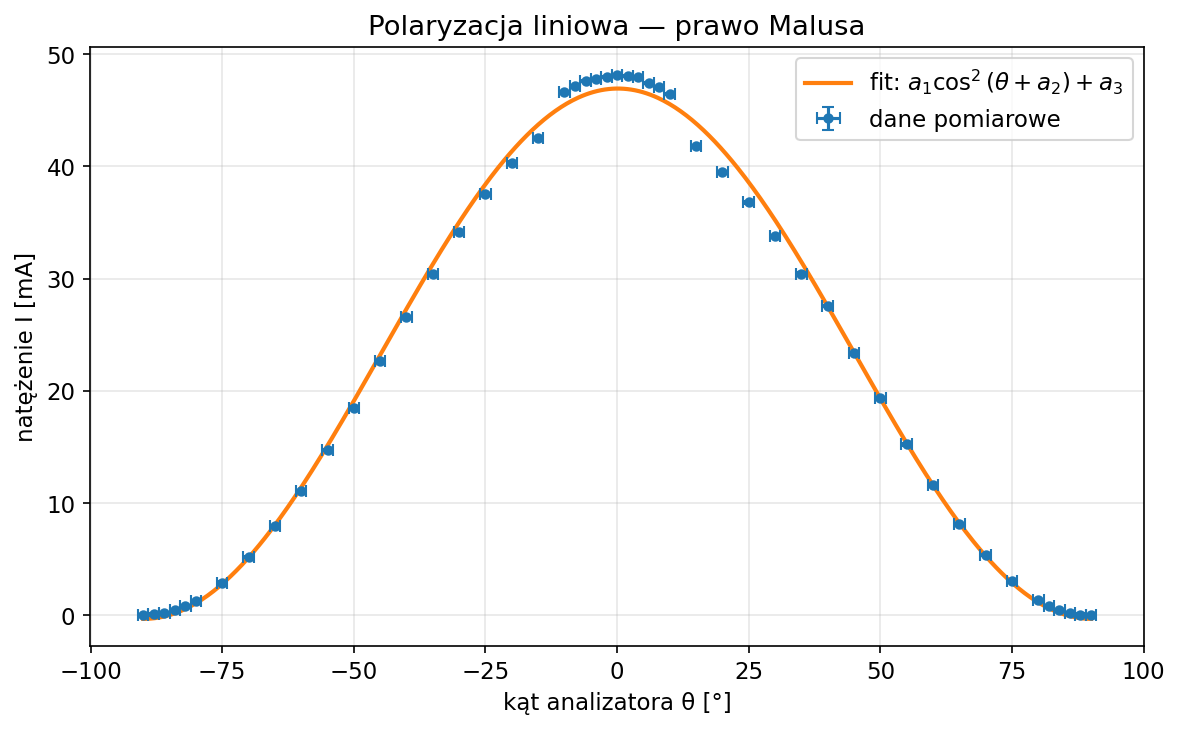

Zapisano: linear_polarization.pdf


In [15]:
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit     = malus(theta_fit, *popt_lin)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(theta, I, yerr=u_I, xerr=df_lin['u_theta'].values,
            fmt='o', ms=4, capsize=3, label='dane pomiarowe', zorder=5)
ax.plot(theta_fit, I_fit, '-', lw=2,
        label=fr'fit: $a_1\cos^2(\theta+a_2)+a_3$')
ax.set_xlabel('kąt analizatora θ [°]')
ax.set_ylabel('natężenie I [mA]')
ax.set_title('Polaryzacja liniowa — prawo Malusa')
ax.legend()
fig.tight_layout()
fig.savefig('linear_polarization.pdf')
plt.show()
print('Zapisano: linear_polarization.pdf')

### Dyskusja — prawo Malusa

Parametr `a3` reprezentuje tło (prąd ciemny + niepełna ekstynkcja polaryzatora). Jeśli `a1 >> a3`, światło za polaryzatorem jest bliskie liniowo spolaryzowanemu. Przesunięcie `a2` wskazuje, że maksimum natężenia nie leży dokładnie w θ=0 — oś transmisji polaryzatora jest obrócona o `a2` względem skali kątowej.

## 2. Wyznaczenie azymutu ćwierćfalówki nr 1

In [16]:
df_qwp1 = pd.read_csv('qwp_1_azimuth.csv')
df_qwp1

,theta,u_theta,I,u_I
0,-30,1,32.41,0.1
1,-29,1,32.18,0.1
2,-28,1,32.54,0.1
3,-27,1,32.54,0.1
4,-26,1,32.50,0.1
5,-25,1,32.20,0.1
6,-24,1,32.25,0.1
7,-23,1,32.04,0.1
8,66,1,9.42,0.1
9,65,1,9.37,0.1


In [17]:
# Dwa zakresy: okolice maksimum (~-27°) i minimum (~63°)
mask_max = df_qwp1['theta'] < 0
mask_min = df_qwp1['theta'] > 0

df_max = df_qwp1[mask_max]
df_min = df_qwp1[mask_min]

# Azymut maksimum: kąt przy największym I
idx_max = df_max['I'].idxmax()
azimuth_max_qwp1 = df_qwp1.loc[idx_max, 'theta']

# Azymut minimum: kąt przy najmniejszym I
idx_min = df_min['I'].idxmin()
azimuth_min_qwp1 = df_qwp1.loc[idx_min, 'theta']

# Niepewność azymutu: rozrzut kątów dla których I jest w zakresie I_extr ± u_I
# metoda: zakres kątów gdzie I <= I_min + u_I (dla minimum)
I_min_val = df_min['I'].min()
u_I_val   = df_qwp1['u_I'].iloc[0]
katy_min  = df_min.loc[df_min['I'] <= I_min_val + u_I_val, 'theta']
u_azimuth_qwp1 = (katy_min.max() - katy_min.min()) / 2 if len(katy_min) > 1 else u_I_val

# Wybrane azymuty zgodnie z informacją z laboratorium
azimuth_A_qwp1 = -27  # maksimum transmisji
azimuth_B_qwp1 =  63  # minimum transmisji

print(f"Azymut ćwierćfalówki QWP1 (maksimum): {azimuth_A_qwp1}°")
print(f"Azymut ćwierćfalówki QWP1 (minimum):  {azimuth_B_qwp1}°")
print(f"Różnica kątów: {azimuth_B_qwp1 - azimuth_A_qwp1}° (powinno być ~90°)")
print(f"Niepewność azymutu (z rozrzutu): ±{u_azimuth_qwp1:.1f}° ")
print(f"Przyjęta niepewność azymutu: ±1° (rozdzielczość skali)")
u_az_qwp1 = 1.0  # °

Azymut ćwierćfalówki QWP1 (maksimum): -27°
Azymut ćwierćfalówki QWP1 (minimum):  63°
Różnica kątów: 90° (powinno być ~90°)
Niepewność azymutu (z rozrzutu): ±3.5° 
Przyjęta niepewność azymutu: ±1° (rozdzielczość skali)


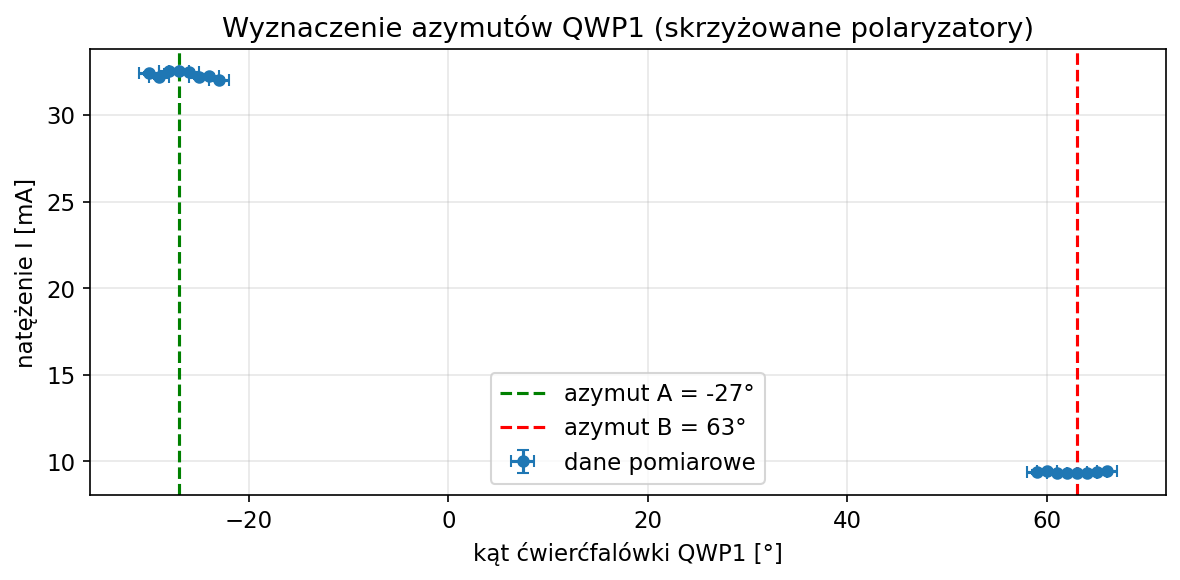

Zapisano: qwp_schematics.pdf


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(df_qwp1['theta'], df_qwp1['I'], yerr=df_qwp1['u_I'], xerr=df_qwp1['u_theta'],
            fmt='o', ms=5, capsize=3, label='dane pomiarowe')
ax.axvline(azimuth_A_qwp1, color='green', ls='--', label=f'azymut A = {azimuth_A_qwp1}°')
ax.axvline(azimuth_B_qwp1, color='red',   ls='--', label=f'azymut B = {azimuth_B_qwp1}°')
ax.set_xlabel('kąt ćwierćfalówki QWP1 [°]')
ax.set_ylabel('natężenie I [mA]')
ax.set_title('Wyznaczenie azymutów QWP1 (skrzyżowane polaryzatory)')
ax.legend()
fig.tight_layout()
fig.savefig('qwp_schematics.pdf')
plt.show()
print('Zapisano: qwp_schematics.pdf')

## 3. Polaryzacja kołowa (QWP1 pod 18°, kąt do azymutu = 45°)

In [19]:
df_circ = pd.read_csv('circular_polarization.csv')
df_circ

,theta,u_theta,I,u_I
0,-90,1,2.62,0.1
1,-85,1,4.09,0.1
2,-80,1,6.05,0.1
3,-75,1,8.39,0.1
4,-70,1,11.25,0.1
5,-65,1,14.23,0.1
6,-60,1,17.91,0.1
7,-55,1,21.23,0.1
8,-50,1,24.88,0.1
9,-45,1,28.48,0.1


In [20]:
theta_c = df_circ['theta'].values
I_c     = df_circ['I'].values
u_I_c   = df_circ['u_I'].values

p0_c = [(I_c.max()-I_c.min())/2, 0, I_c.mean()]
popt_c, pcov_c = curve_fit(malus, theta_c, I_c, p0=p0_c, sigma=u_I_c, absolute_sigma=True)
perr_c = np.sqrt(np.diag(pcov_c))

a1c, a2c, a3c = popt_c
u_a1c, u_a2c, u_a3c = perr_c

I_max_c = a1c + a3c
I_min_c = a3c
u_Imax_c = np.sqrt(u_a1c**2 + u_a3c**2)
u_Imin_c = u_a3c

# Eliptyczność e = sqrt(I_min / I_max)
e_circ = np.sqrt(I_min_c / I_max_c)
# Propagacja niepewności: u_e = (1/2) * (1/sqrt(I_min/I_max)) * sqrt((u_Imin/I_max)^2 + (I_min*u_Imax/I_max^2)^2)
u_e_circ = 0.5 / e_circ * np.sqrt((u_Imin_c/I_max_c)**2 + (I_min_c*u_Imax_c/I_max_c**2)**2)

print(f"a1 = {a1c:.3f} ± {u_a1c:.3f}")
print(f"a2 = {a2c:.3f} ± {u_a2c:.3f} °")
print(f"a3 = {a3c:.3f} ± {u_a3c:.3f}")
print()
print(f"I_max = {I_max_c:.3f} ± {u_Imax_c:.3f}")
print(f"I_min = {I_min_c:.3f} ± {u_Imin_c:.3f}")
print()
print(f"Eliptyczność eksperymentalna e = sqrt(I_min/I_max) = {e_circ:.4f} ± {u_e_circ:.4f}")
print(f"Eliptyczność teoretyczna (polaryzacja kołowa): e = 1")
print()
kąt_qwp_circ = 18  # °
theta_rel_circ = abs(kąt_qwp_circ - azimuth_A_qwp1)
e_teor_circ = abs(np.tan(np.deg2rad(theta_rel_circ)))
print(f"Kąt między polaryzatorem a azymutami QWP1: {theta_rel_circ}°")
print(f"Eliptyczność teoretyczna |tan({theta_rel_circ}°)| = {e_teor_circ:.4f}")

a1 = 40.672 ± 0.046
a2 = 10.092 ± 0.033 °
a3 = 1.234 ± 0.028

I_max = 41.907 ± 0.054
I_min = 1.234 ± 0.028

Eliptyczność eksperymentalna e = sqrt(I_min/I_max) = 0.1716 ± 0.0019
Eliptyczność teoretyczna (polaryzacja kołowa): e = 1

Kąt między polaryzatorem a azymutami QWP1: 45°
Eliptyczność teoretyczna |tan(45°)| = 1.0000


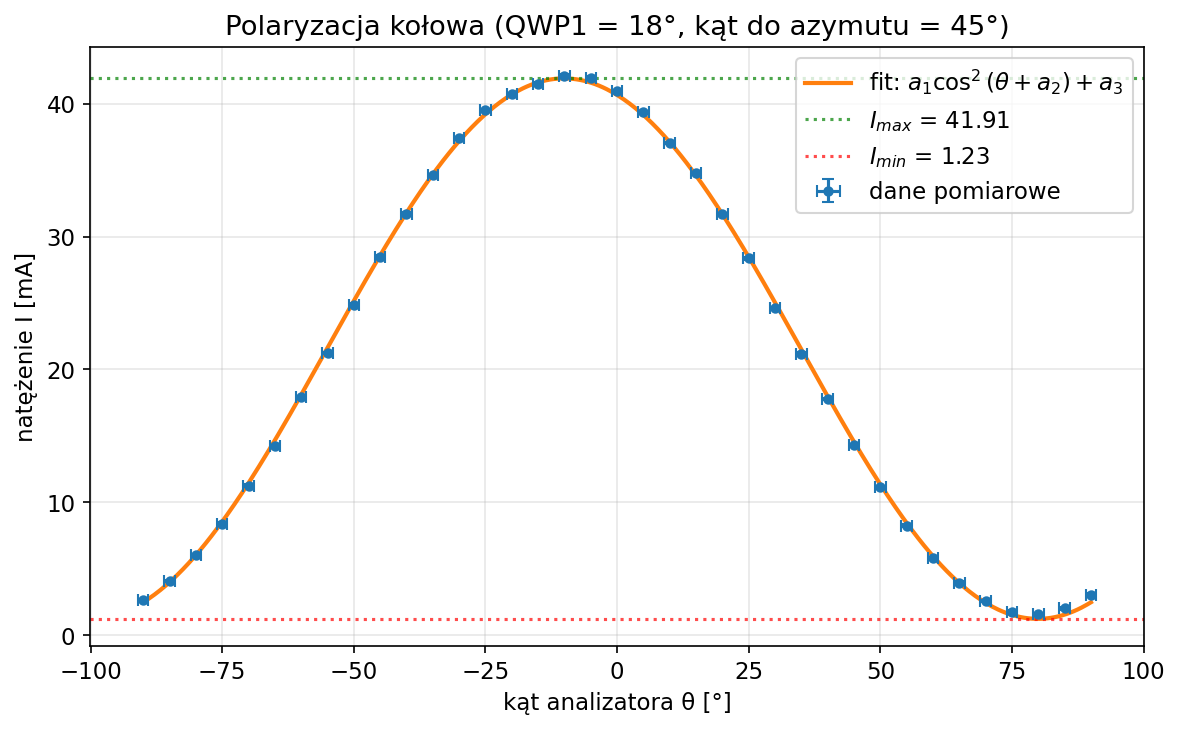

Zapisano: circular_polarization.pdf


In [21]:
theta_fit_c = np.linspace(theta_c.min(), theta_c.max(), 500)
I_fit_c     = malus(theta_fit_c, *popt_c)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(theta_c, I_c, yerr=u_I_c, xerr=df_circ['u_theta'].values,
            fmt='o', ms=4, capsize=3, label='dane pomiarowe', zorder=5)
ax.plot(theta_fit_c, I_fit_c, '-', lw=2, label=fr'fit: $a_1\cos^2(\theta+a_2)+a_3$')
ax.axhline(I_max_c, color='green', ls=':', alpha=0.7, label=f'$I_{{max}}$ = {I_max_c:.2f}')
ax.axhline(I_min_c, color='red',   ls=':', alpha=0.7, label=f'$I_{{min}}$ = {I_min_c:.2f}')
ax.set_xlabel('kąt analizatora θ [°]')
ax.set_ylabel('natężenie I [mA]')
ax.set_title('Polaryzacja kołowa (QWP1 = 18°, kąt do azymutu = 45°)')
ax.legend()
fig.tight_layout()
fig.savefig('circular_polarization.pdf')
plt.show()
print('Zapisano: circular_polarization.pdf')

## 4. & 5. Polaryzacje eliptyczne

=== Polaryzacja eliptyczna 1 (QWP1 = -12°) ===
  Ustawienie QWP: -12°, azymut QWP: -27°
  Kąt względny θ_rel = 15°
  a1 = 9.163 ± 0.047
  a2 = 31.170 ± 0.144 °
  a3 = 17.917 ± 0.028
  I_max = 27.080 ± 0.055
  I_min = 17.917 ± 0.028
  Oś główna elipsy: -31.17 ± 0.14 °
  Eliptyczność eksperymentalna: e = 0.8134 ± 0.0010
  Eliptyczność teoretyczna |tan(15°)|: e = 0.2679 ± 0.0265



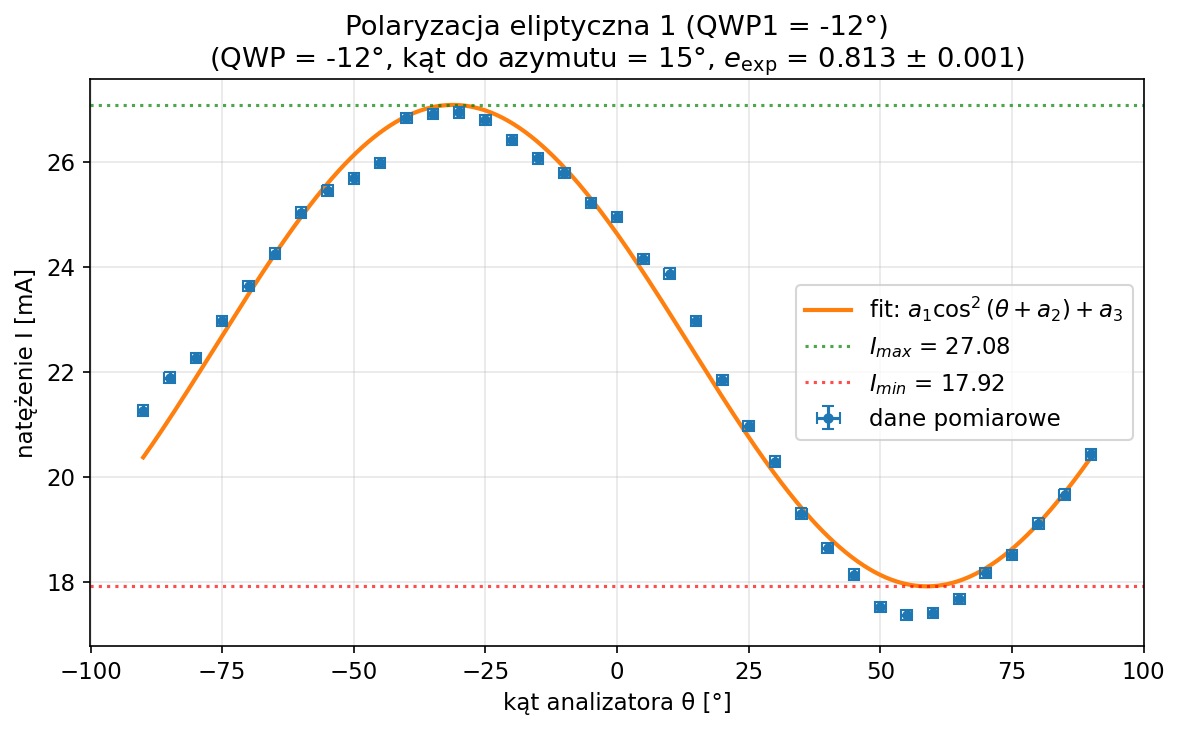

Zapisano: eliptical_polarization_1.pdf
=== Polaryzacja eliptyczna 2 (QWP1 = -42°) ===
  Ustawienie QWP: -42°, azymut QWP: -27°
  Kąt względny θ_rel = 15°
  a1 = 32.715 ± 0.046
  a2 = -20.431 ± 0.041 °
  a3 = 6.080 ± 0.028
  I_max = 38.795 ± 0.054
  I_min = 6.080 ± 0.028
  Oś główna elipsy: 20.43 ± 0.04 °
  Eliptyczność eksperymentalna: e = 0.3959 ± 0.0010
  Eliptyczność teoretyczna |tan(15°)|: e = 0.2679 ± 0.0265



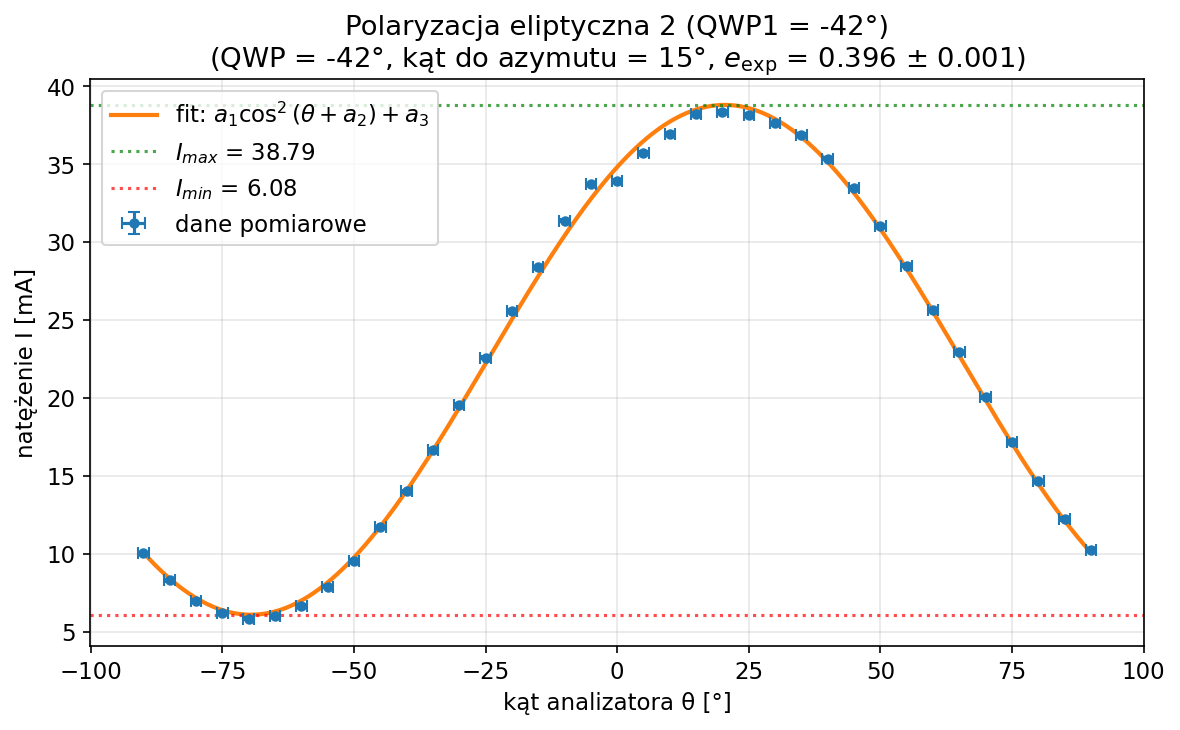

Zapisano: eliptical_polarization_2.pdf


In [22]:
df_el1 = pd.read_csv('eliptical_polarization_1.csv')
df_el2 = pd.read_csv('eliptical_polarization_2.csv')

# Kąty ustawienia ćwierćfalówki
qwp_angle_el1 = -12  # °
qwp_angle_el2 = -42  # °

def fit_elliptic(df, qwp_angle, azimuth_qwp, u_az, label, pdf_name):
    theta = df['theta'].values
    I     = df['I'].values
    u_I   = df['u_I'].values

    p0 = [(I.max()-I.min())/2, 0, I.min()]
    popt, pcov = curve_fit(malus, theta, I, p0=p0, sigma=u_I, absolute_sigma=True)
    perr = np.sqrt(np.diag(pcov))
    a1, a2, a3 = popt
    u_a1, u_a2, u_a3 = perr

    I_max = a1 + a3
    I_min = a3
    u_Imax = np.sqrt(u_a1**2 + u_a3**2)
    u_Imin = u_a3

    # Eliptyczność eksperymentalna e = sqrt(I_min/I_max)
    e_exp = np.sqrt(abs(I_min / I_max))
    u_e_exp = 0.5 / e_exp * np.sqrt((u_Imin/I_max)**2 + (I_min*u_Imax/I_max**2)**2)

    # Eliptyczność teoretyczna: e = |tan(theta_rel)|
    theta_rel = abs(qwp_angle - azimuth_qwp)
    if theta_rel > 90:
        theta_rel = 180 - theta_rel
    e_teor = abs(np.tan(np.deg2rad(theta_rel)))
    # Niepewność teoretyczna: u_e_teor = |1/cos^2(theta_rel)| * u_theta_rel [rad]
    # u_theta_rel = sqrt(u_qwp^2 + u_az^2) — niepewność kąta ćwierćfalówki + azymutu
    u_theta_rel = np.sqrt(1.0**2 + u_az**2)  # u_qwp = 1°
    u_e_teor = (1/np.cos(np.deg2rad(theta_rel))**2) * np.deg2rad(u_theta_rel)

    # Oś główna elipsy (kąt polaryzacji maksimum) = -a2
    main_axis = -a2

    print(f"=== {label} ===")
    print(f"  Ustawienie QWP: {qwp_angle}°, azymut QWP: {azimuth_qwp}°")
    print(f"  Kąt względny θ_rel = {theta_rel}°")
    print(f"  a1 = {a1:.3f} ± {u_a1:.3f}")
    print(f"  a2 = {a2:.3f} ± {u_a2:.3f} °")
    print(f"  a3 = {a3:.3f} ± {u_a3:.3f}")
    print(f"  I_max = {I_max:.3f} ± {u_Imax:.3f}")
    print(f"  I_min = {I_min:.3f} ± {u_Imin:.3f}")
    print(f"  Oś główna elipsy: {main_axis:.2f} ± {u_a2:.2f} °")
    print(f"  Eliptyczność eksperymentalna: e = {e_exp:.4f} ± {u_e_exp:.4f}")
    print(f"  Eliptyczność teoretyczna |tan({theta_rel}°)|: e = {e_teor:.4f} ± {u_e_teor:.4f}")
    print()

    # Wykres
    theta_fit = np.linspace(theta.min(), theta.max(), 500)
    I_fit     = malus(theta_fit, *popt)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(theta, I, yerr=u_I, xerr=df['u_theta'].values,
                fmt='o', ms=4, capsize=3, label='dane pomiarowe', zorder=5)
    ax.plot(theta_fit, I_fit, '-', lw=2, label=fr'fit: $a_1\cos^2(\theta+a_2)+a_3$')
    ax.axhline(I_max, color='green', ls=':', alpha=0.7, label=f'$I_{{max}}$ = {I_max:.2f}')
    ax.axhline(I_min, color='red',   ls=':', alpha=0.7, label=f'$I_{{min}}$ = {I_min:.2f}')
    ax.set_xlabel('kąt analizatora θ [°]')
    ax.set_ylabel('natężenie I [mA]')
    ax.set_title(f'{label}\n(QWP = {qwp_angle}°, kąt do azymutu = {theta_rel}°, $e_\\mathrm{{exp}}$ = {e_exp:.3f} ± {u_e_exp:.3f})')
    ax.legend()
    fig.tight_layout()
    fig.savefig(pdf_name)
    plt.show()
    print(f'Zapisano: {pdf_name}')

    return popt, perr, e_exp, u_e_exp, e_teor, u_e_teor

res_el1 = fit_elliptic(df_el1, qwp_angle_el1, azimuth_A_qwp1, u_az_qwp1,
                       'Polaryzacja eliptyczna 1 (QWP1 = -12°)',
                       'eliptical_polarization_1.pdf')

res_el2 = fit_elliptic(df_el2, qwp_angle_el2, azimuth_A_qwp1, u_az_qwp1,
                       'Polaryzacja eliptyczna 2 (QWP1 = -42°)',
                       'eliptical_polarization_2.pdf')

## 6. Wyznaczenie azymutu ćwierćfalówki nr 2

In [23]:
df_qwp2 = pd.read_csv('qwp_2_azimuth.csv')
df_qwp2

,theta,u_theta,I,u_I
0,-40,1,30.95,0.1
1,-39,1,30.99,0.1
2,-38,1,30.91,0.1
3,-37,1,32.75,0.1
4,-36,1,32.84,0.1
5,-35,1,30.91,0.1
6,-34,1,31.03,0.1
7,51,1,17.66,0.1
8,52,1,17.54,0.1
9,53,1,17.54,0.1


In [24]:
mask_max2 = df_qwp2['theta'] < 0
mask_min2 = df_qwp2['theta'] > 0

df_max2 = df_qwp2[mask_max2]
df_min2 = df_qwp2[mask_min2]

I_min_val2 = df_min2['I'].min()
u_I_val2   = df_qwp2['u_I'].iloc[0]
katy_min2  = df_min2.loc[df_min2['I'] <= I_min_val2 + u_I_val2, 'theta']
u_azimuth_qwp2 = (katy_min2.max() - katy_min2.min()) / 2 if len(katy_min2) > 1 else u_I_val2

azimuth_A_qwp2 = -36  # °  maksimum
azimuth_B_qwp2 =  54  # °  minimum

print(f"Azymut ćwierćfalówki QWP2 (maksimum): {azimuth_A_qwp2}°")
print(f"Azymut ćwierćfalówki QWP2 (minimum):  {azimuth_B_qwp2}°")
print(f"Różnica kątów: {azimuth_B_qwp2 - azimuth_A_qwp2}° (powinno być ~90°)")
print(f"Przyjęta niepewność azymutu QWP2: ±1°")
u_az_qwp2 = 1.0  # °

Azymut ćwierćfalówki QWP2 (maksimum): -36°
Azymut ćwierćfalówki QWP2 (minimum):  54°
Różnica kątów: 90° (powinno być ~90°)
Przyjęta niepewność azymutu QWP2: ±1°


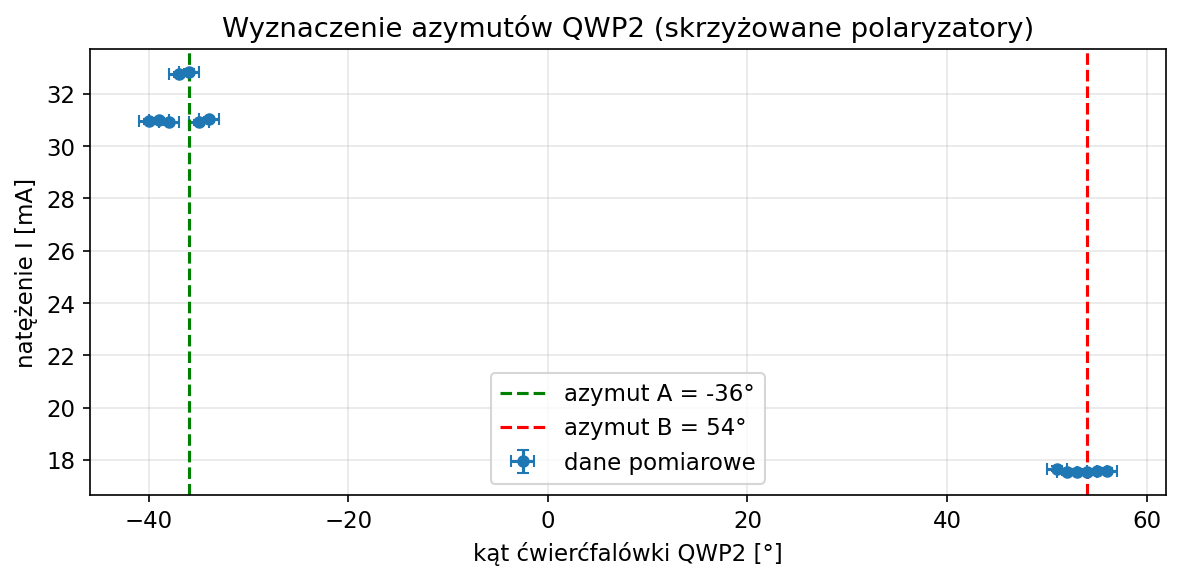

Zapisano: qwp2_azimuth.pdf


In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(df_qwp2['theta'], df_qwp2['I'], yerr=df_qwp2['u_I'], xerr=df_qwp2['u_theta'],
            fmt='o', ms=5, capsize=3, label='dane pomiarowe')
ax.axvline(azimuth_A_qwp2, color='green', ls='--', label=f'azymut A = {azimuth_A_qwp2}°')
ax.axvline(azimuth_B_qwp2, color='red',   ls='--', label=f'azymut B = {azimuth_B_qwp2}°')
ax.set_xlabel('kąt ćwierćfalówki QWP2 [°]')
ax.set_ylabel('natężenie I [mA]')
ax.set_title('Wyznaczenie azymutów QWP2 (skrzyżowane polaryzatory)')
ax.legend()
fig.tight_layout()
fig.savefig('qwp2_azimuth.pdf')
plt.show()
print('Zapisano: qwp2_azimuth.pdf')

## 7. Dwie ćwierćfalówki jako półfalówka

In [26]:
df_both = pd.read_csv('qwp_both.csv')
df_both

,theta,u_theta,I,u_I
0,-90,1,0.10,0.1
1,-85,1,0.20,0.1
2,-80,1,0.87,0.1
3,-75,1,2.08,0.1
4,-70,1,3.87,0.1
5,-65,1,6.13,0.1
6,-60,1,8.68,0.1
7,-55,1,11.64,0.1
8,-50,1,14.87,0.1
9,-45,1,18.24,0.1


In [27]:
theta_b = df_both['theta'].values
I_b     = df_both['I'].values
u_I_b   = df_both['u_I'].values

p0_b = [(I_b.max()-I_b.min())/2, 0, I_b.min()]
popt_b, pcov_b = curve_fit(malus, theta_b, I_b, p0=p0_b, sigma=u_I_b, absolute_sigma=True)
perr_b = np.sqrt(np.diag(pcov_b))

a1b, a2b, a3b = popt_b
u_a1b, u_a2b, u_a3b = perr_b

I_max_b = a1b + a3b
I_min_b = a3b
u_Imax_b = np.sqrt(u_a1b**2 + u_a3b**2)
u_Imin_b = u_a3b

# Kierunek polaryzacji wyjściowej
pol_out = -a2b

# Teoretyczne obrócenie polaryzacji przez półfalówkę:
# Polaryzacja wejściowa: 0° (polaryzator)
# Azymut QWP1 = -27°, azymut QWP2 = -36°
# Układ QWP1+QWP2 działa jak półfalówka jeśli różnica azymutów = 45°
# Obrócenie: nowa polaryzacja = 2*azymut_efektywny - polaryzacja_wejściowa
# Dla półfalówki o azymucie φ: wyjście = 2φ - wejście
# Tu używamy azymutu QWP1 jako pierwszej płytki
phi_hwp = azimuth_A_qwp1  # efektywny azymut półfalówki = azymut QWP1
pol_in  = 0.0  # polaryzacja wejściowa [°]
pol_teor = 2 * phi_hwp - pol_in
# Niepewność: u_pol_teor = 2 * u_az_qwp1
u_pol_teor = 2 * u_az_qwp1

print(f"a1 = {a1b:.3f} ± {u_a1b:.3f}")
print(f"a2 = {a2b:.3f} ± {u_a2b:.3f} °")
print(f"a3 = {a3b:.3f} ± {u_a3b:.3f}")
print()
print(f"I_max = {I_max_b:.3f} ± {u_Imax_b:.3f}")
print(f"I_min = {I_min_b:.3f} ± {u_Imin_b:.3f}")
print(f"Kontrast (I_max-I_min)/(I_max+I_min) = {(I_max_b-I_min_b)/(I_max_b+I_min_b):.4f}")
print()
print(f"Kierunek polaryzacji wyjściowej (eksperyment): {pol_out:.2f} ± {u_a2b:.2f} °")
print(f"Kierunek polaryzacji wyjściowej (teoria):      {pol_teor:.2f} ± {u_pol_teor:.2f} °")
print(f"(półfalówka obraca polaryzację o 2*azymut = 2×{phi_hwp}° = {2*phi_hwp}°)")

a1 = 38.621 ± 0.046
a2 = -1.257 ± 0.035 °
a3 = -0.115 ± 0.028

I_max = 38.507 ± 0.054
I_min = -0.115 ± 0.028
Kontrast (I_max-I_min)/(I_max+I_min) = 1.0060

Kierunek polaryzacji wyjściowej (eksperyment): 1.26 ± 0.03 °
Kierunek polaryzacji wyjściowej (teoria):      -54.00 ± 2.00 °
(półfalówka obraca polaryzację o 2*azymut = 2×-27° = -54°)


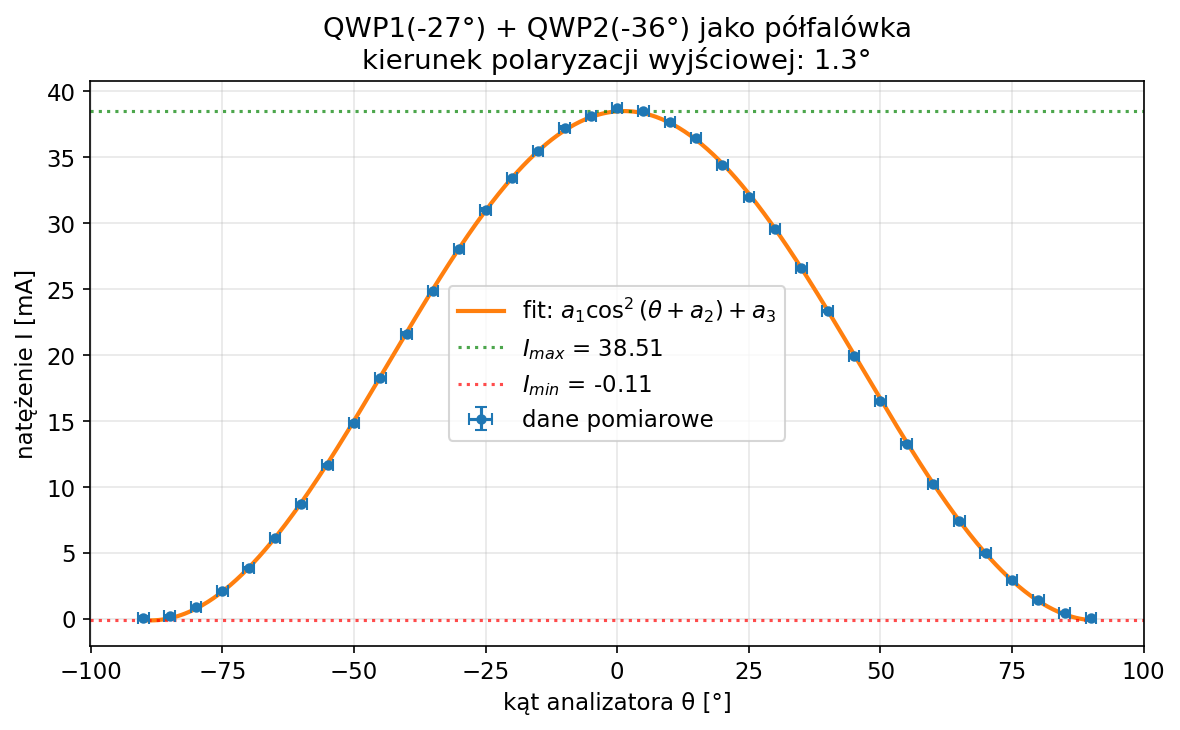

Zapisano: qwp_both.pdf


In [28]:
theta_fit_b = np.linspace(theta_b.min(), theta_b.max(), 500)
I_fit_b     = malus(theta_fit_b, *popt_b)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(theta_b, I_b, yerr=u_I_b, xerr=df_both['u_theta'].values,
            fmt='o', ms=4, capsize=3, label='dane pomiarowe', zorder=5)
ax.plot(theta_fit_b, I_fit_b, '-', lw=2, label=fr'fit: $a_1\cos^2(\theta+a_2)+a_3$')
ax.axhline(I_max_b, color='green', ls=':', alpha=0.7, label=f'$I_{{max}}$ = {I_max_b:.2f}')
ax.axhline(I_min_b, color='red',   ls=':', alpha=0.7, label=f'$I_{{min}}$ = {I_min_b:.2f}')
ax.set_xlabel('kąt analizatora θ [°]')
ax.set_ylabel('natężenie I [mA]')
ax.set_title(f'QWP1(-27°) + QWP2(-36°) jako półfalówka\nkierunek polaryzacji wyjściowej: {pol_out:.1f}°')
ax.legend()
fig.tight_layout()
fig.savefig('qwp_both.pdf')
plt.show()
print('Zapisano: qwp_both.pdf')

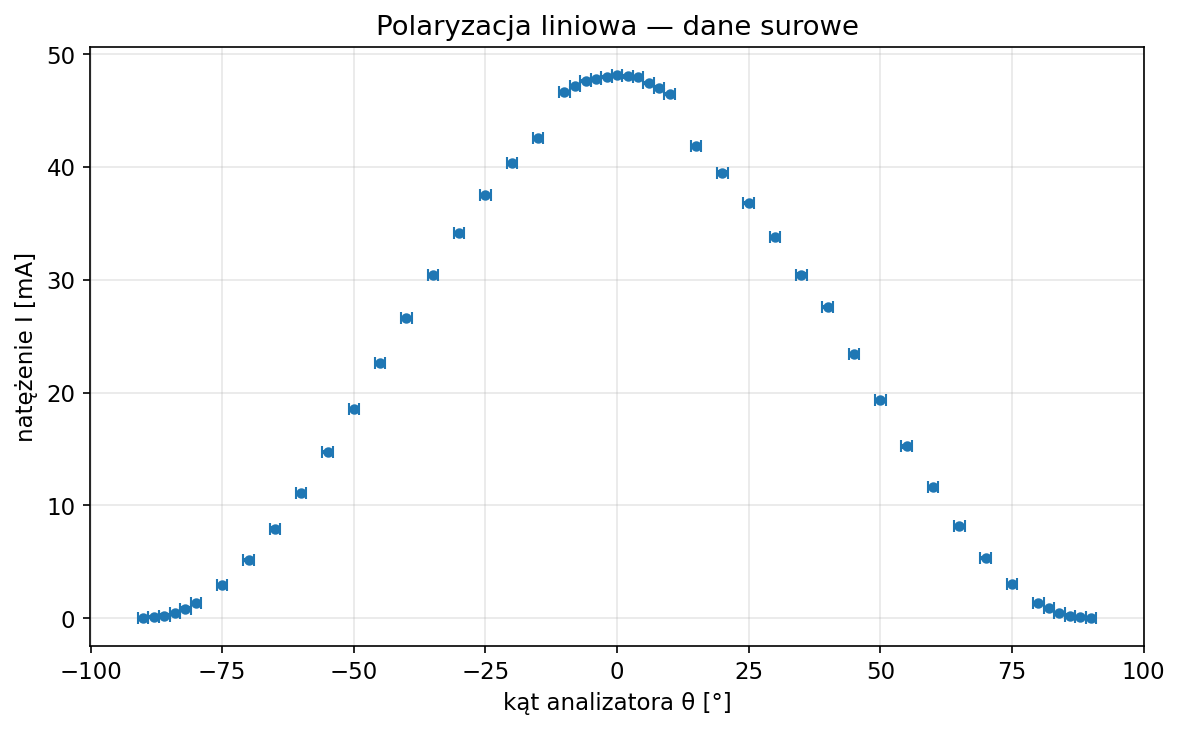

Zapisano: linear_polarization_raw.pdf


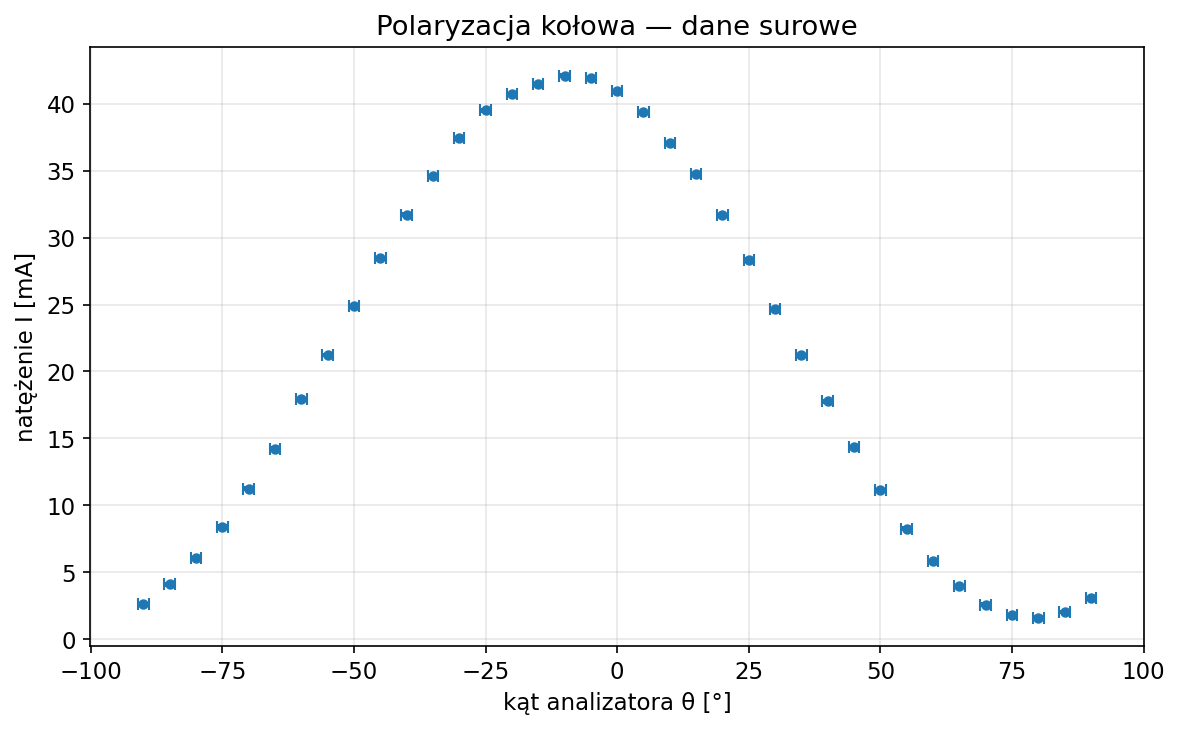

Zapisano: circular_polarization_raw.pdf


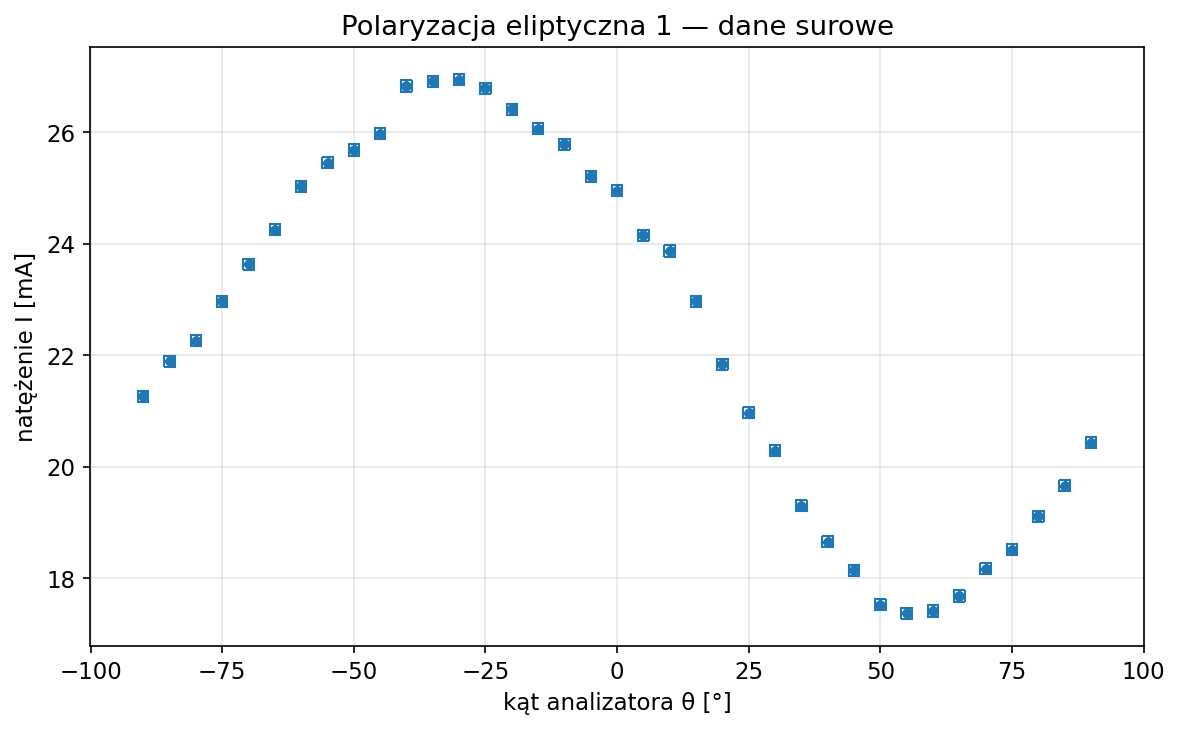

Zapisano: eliptical_polarization_1_raw.pdf


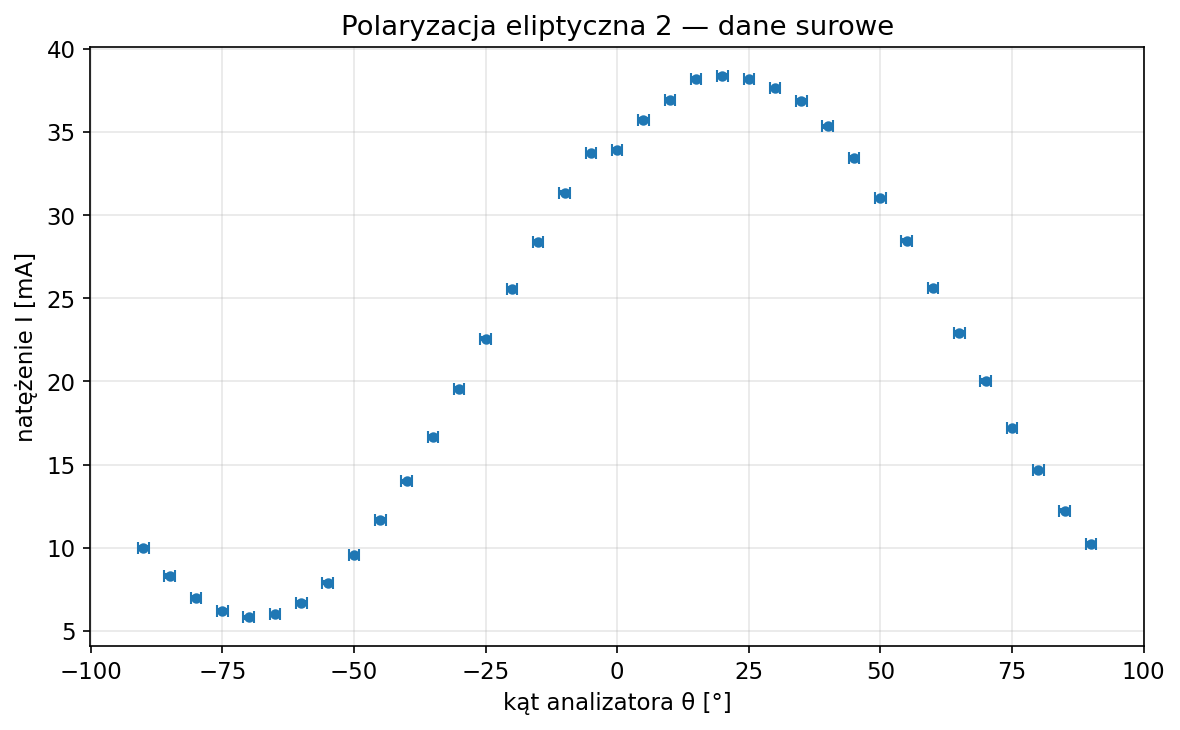

Zapisano: eliptical_polarization_2_raw.pdf


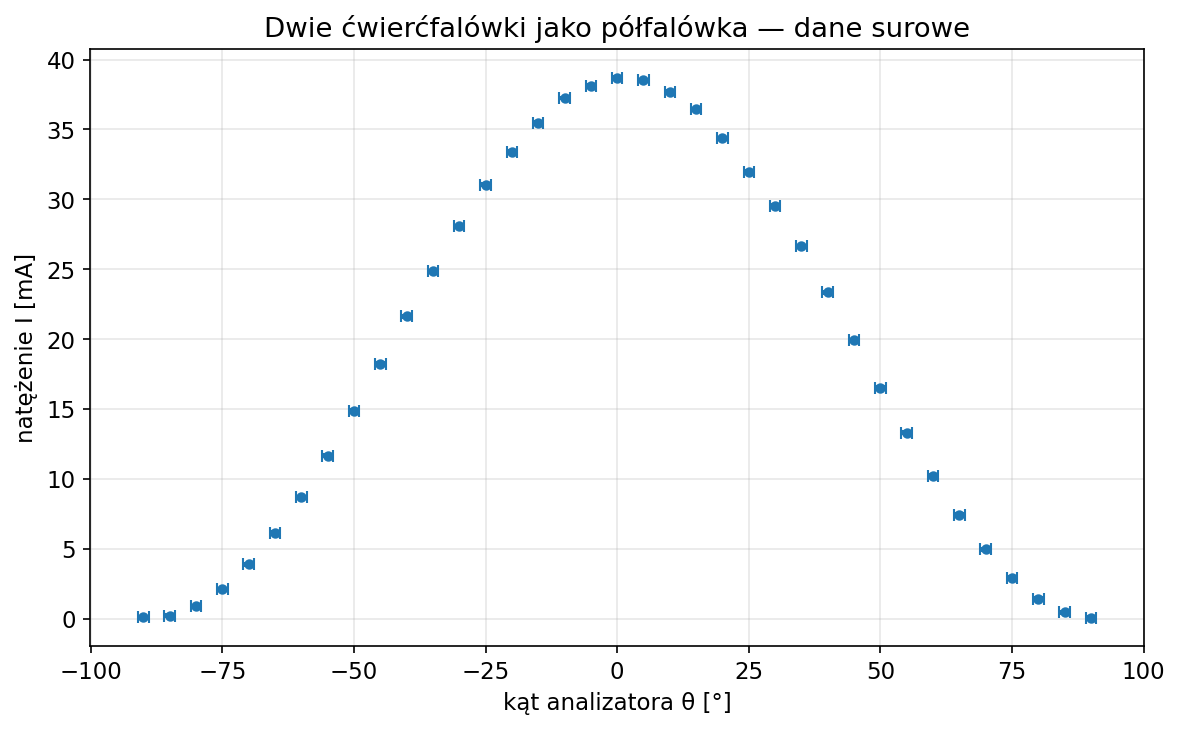

Zapisano: qwp_both_raw.pdf


In [29]:
# Wykresy surowych danych (bez dopasowanych krzywych) — do sekcji Wyniki pomiarów

def plot_raw(df, xlabel, title, pdf_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(df['theta'], df['I'], yerr=df['u_I'], xerr=df['u_theta'],
                fmt='o', ms=4, capsize=3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('natężenie I [mA]')
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(pdf_name)
    plt.show()
    print(f'Zapisano: {pdf_name}')

plot_raw(df_lin,
         'kąt analizatora θ [°]',
         'Polaryzacja liniowa — dane surowe',
         'linear_polarization_raw.pdf')

plot_raw(df_circ,
         'kąt analizatora θ [°]',
         'Polaryzacja kołowa — dane surowe',
         'circular_polarization_raw.pdf')

plot_raw(df_el1,
         'kąt analizatora θ [°]',
         'Polaryzacja eliptyczna 1 — dane surowe',
         'eliptical_polarization_1_raw.pdf')

plot_raw(df_el2,
         'kąt analizatora θ [°]',
         'Polaryzacja eliptyczna 2 — dane surowe',
         'eliptical_polarization_2_raw.pdf')

plot_raw(df_both,
         'kąt analizatora θ [°]',
         'Dwie ćwierćfalówki jako półfalówka — dane surowe',
         'qwp_both_raw.pdf')

## Podsumowanie wyników

In [30]:
print("=" * 60)
print("PODSUMOWANIE WYNIKÓW")
print("=" * 60)

print("\n1. PRAWO MALUSA")
a1, a2, a3 = popt_lin
u_a1, u_a2, u_a3 = perr_lin
print(f"   I_max = {a1+a3:.3f} ± {np.sqrt(u_a1**2+u_a3**2):.3f}")
print(f"   I_min = {a3:.3f} ± {u_a3:.3f}")
print(f"   Kierunek polaryzacji (a2) = {a2:.2f} ± {u_a2:.2f} °")
print(f"   Tło a3/I_max = {a3/(a1+a3)*100:.2f} %  → światło prawie liniowo spolaryzowane")

print("\n2. AZYMUTY QWP1")
print(f"   Azymut A (maksimum) = {azimuth_A_qwp1} ± {u_az_qwp1:.0f} °")
print(f"   Azymut B (minimum)  = {azimuth_B_qwp1} ± {u_az_qwp1:.0f} °")

print("\n3. POLARYZACJA KOŁOWA")
print(f"   e_exp = {e_circ:.4f} ± {u_e_circ:.4f}")
print(f"   e_teor = {e_teor_circ:.4f}  (|tan(45°)| = 1)")

print("\n4. POLARYZACJA ELIPTYCZNA 1 (QWP = -12°, kąt do az. = 15°)")
popt4, perr4, e4_exp, u_e4_exp, e4_teor, u_e4_teor = res_el1
print(f"   Oś główna elipsy = {-popt4[1]:.2f} ± {perr4[1]:.2f} °")
print(f"   e_exp  = {e4_exp:.4f} ± {u_e4_exp:.4f}")
print(f"   e_teor = {e4_teor:.4f} ± {u_e4_teor:.4f}  (|tan(15°)|)")

print("\n5. POLARYZACJA ELIPTYCZNA 2 (QWP = -42°, kąt do az. = 15°)")
popt5, perr5, e5_exp, u_e5_exp, e5_teor, u_e5_teor = res_el2
print(f"   Oś główna elipsy = {-popt5[1]:.2f} ± {perr5[1]:.2f} °")
print(f"   e_exp  = {e5_exp:.4f} ± {u_e5_exp:.4f}")
print(f"   e_teor = {e5_teor:.4f} ± {u_e5_teor:.4f}  (|tan(15°)|)")

print("\n6. AZYMUTY QWP2")
print(f"   Azymut A (maksimum) = {azimuth_A_qwp2} ± {u_az_qwp2:.0f} °")
print(f"   Azymut B (minimum)  = {azimuth_B_qwp2} ± {u_az_qwp2:.0f} °")

print("\n7. QWP1 + QWP2 JAKO PÓŁFALÓWKA")
print(f"   Kierunek polaryzacji wyjściowej (eksp.) = {-popt_b[1]:.2f} ± {perr_b[1]:.2f} °")
print(f"   Kierunek polaryzacji wyjściowej (teor.) = {pol_teor:.2f} ± {u_pol_teor:.2f} °")
print(f"   Kontrast = {(I_max_b-I_min_b)/(I_max_b+I_min_b):.4f}  (→ 1 dla idealnej polaryzacji liniowej)")
print("=" * 60)

PODSUMOWANIE WYNIKÓW

1. PRAWO MALUSA
   I_max = 46.944 ± 0.043
   I_min = -0.309 ± 0.023
   Kierunek polaryzacji (a2) = -0.13 ± 0.03 °
   Tło a3/I_max = -0.66 %  → światło prawie liniowo spolaryzowane

2. AZYMUTY QWP1
   Azymut A (maksimum) = -27 ± 1 °
   Azymut B (minimum)  = 63 ± 1 °

3. POLARYZACJA KOŁOWA
   e_exp = 0.1716 ± 0.0019
   e_teor = 1.0000  (|tan(45°)| = 1)

4. POLARYZACJA ELIPTYCZNA 1 (QWP = -12°, kąt do az. = 15°)
   Oś główna elipsy = -31.17 ± 0.14 °
   e_exp  = 0.8134 ± 0.0010
   e_teor = 0.2679 ± 0.0265  (|tan(15°)|)

5. POLARYZACJA ELIPTYCZNA 2 (QWP = -42°, kąt do az. = 15°)
   Oś główna elipsy = 20.43 ± 0.04 °
   e_exp  = 0.3959 ± 0.0010
   e_teor = 0.2679 ± 0.0265  (|tan(15°)|)

6. AZYMUTY QWP2
   Azymut A (maksimum) = -36 ± 1 °
   Azymut B (minimum)  = 54 ± 1 °

7. QWP1 + QWP2 JAKO PÓŁFALÓWKA
   Kierunek polaryzacji wyjściowej (eksp.) = 1.26 ± 0.03 °
   Kierunek polaryzacji wyjściowej (teor.) = -54.00 ± 2.00 °
   Kontrast = 1.0060  (→ 1 dla idealnej polaryzacji 